In [235]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi okumak (pandas), görselleştirmek (seaborn) ve ekrana basmak (matplotlib)

In [ ]:
import os
print(os.getcwd())
#File Not Found hatasının neden verdıgını anlamak için

C:\Users\aysim\AppData\Local\Programs\Microsoft VS Code


In [ ]:
df_eff = pd.read_csv(r"C:\Users\aysim\Downloads\Sleep-Analysis-data\Sleep_Efficiency.csv")
df_health = pd.read_csv(r"C:\Users\aysim\Downloads\Sleep_health_and_lifestyle_dataset.csv")
df_act = pd.read_csv(r"C:\Users\aysim\Downloads\health_activity_data.csv")
df_sleep = pd.read_csv(r"C:\Users\aysim\Downloads\Sleep-Analysis-data\sleep_deprivation_dataset_detailed.csv")
#veri setlerini okuduk


In [ ]:
df_final = pd.concat([df_eff, df_health, df_act], axis=1)

df_final = df_final.dropna()
#verı birleştirmek işlemı yaptık çünkü elımızde bırden fazla verı setı var. dropna ile de gereksiz sütünları sildik.


c:\Users\aysim\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\aysim\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


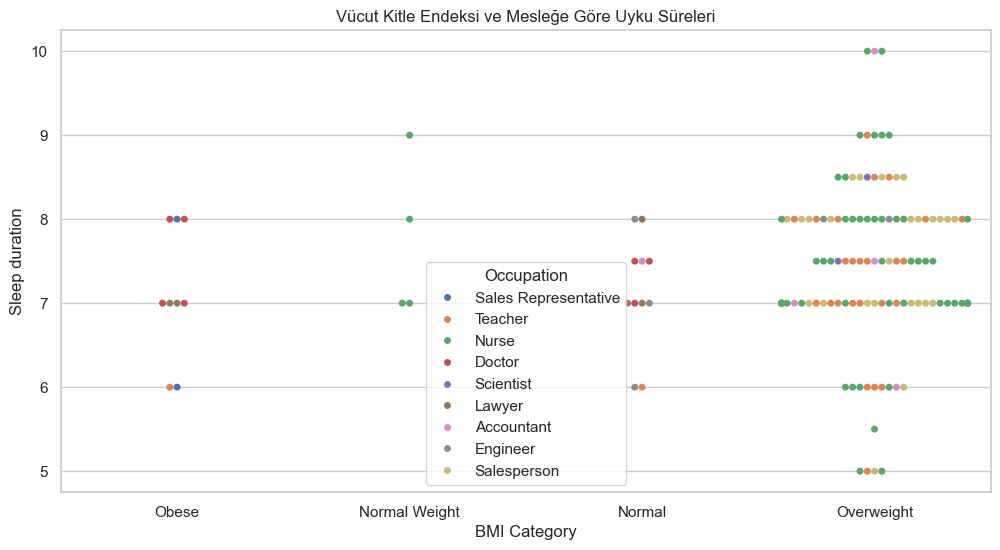

In [ ]:
plt.figure(figsize=(12,6))

sns.swarmplot(data=df_final, x='BMI Category', y='Sleep duration', hue='Occupation')

plt.title('Vücut Kitle Endeksi ve Mesleğe Göre Uyku Süreleri')
plt.show()
#mesleklere göre uyku sürelerını karşılaştırdık ve ilginç bir ilişki aradık.

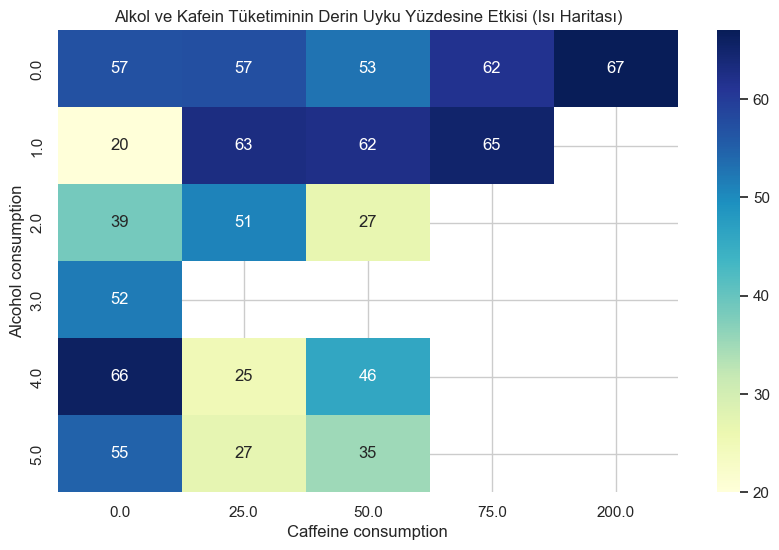

In [ ]:
#ısı haritası çizdirme
plt.figure(figsize=(10,6))
pivot_table = df_final.pivot_table(values='Deep sleep percentage', 
                                   index='Alcohol consumption', 
                                   columns='Caffeine consumption')

sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')

plt.title('Alkol ve Kafein Tüketiminin Derin Uyku Yüzdesine Etkisi (Isı Haritası)')
plt.show()
#alkol ve kafeinin derın uykuya etkısıne baktık. Bu tablo hıpotezımızı oluşturmamızda bıze yardımcı oldu.


In [241]:
print(df_act.columns)
print(df_sleep.columns)
print(df_eff.columns)
print(df_health.columns)

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Steps',
       'Calories_Intake', 'Hours_of_Sleep', 'Heart_Rate', 'Blood_Pressure',
       'Exercise_Hours_per_Week', 'Smoker', 'Alcohol_Consumption_per_Week',
       'Diabetic', 'Heart_Disease'],
      dtype='str')
Index(['Participant_ID', 'Sleep_Hours', 'Sleep_Quality_Score',
       'Daytime_Sleepiness', 'Stroop_Task_Reaction_Time', 'N_Back_Accuracy',
       'Emotion_Regulation_Score', 'PVT_Reaction_Time', 'Age', 'Gender', 'BMI',
       'Caffeine_Intake', 'Physical_Activity_Level', 'Stress_Level'],
      dtype='str')
Index(['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration',
       'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency'],
      dtype='str')
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep'

In [242]:
df_activity = df_act.dropna()
df_sleep = df_sleep.dropna()
df_eff = df_eff.dropna()
df_health = df_health.dropna()

In [243]:
df = pd.concat([df_sleep, df_eff, df_health], axis=1)
df = df.dropna()

In [244]:
print(df.columns)

Index(['Participant_ID', 'Sleep_Hours', 'Sleep_Quality_Score',
       'Daytime_Sleepiness', 'Stroop_Task_Reaction_Time', 'N_Back_Accuracy',
       'Emotion_Regulation_Score', 'PVT_Reaction_Time', 'Age', 'Gender', 'BMI',
       'Caffeine_Intake', 'Physical_Activity_Level', 'Stress_Level', 'ID',
       'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration',
       'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency',
       'Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
#tüm sütun isimlerini standart bir formata getirdik.

In [ ]:
df_numeric = df.select_dtypes(include=["int64", "float64"])
corr = df_numeric.corr()
#korelasyon sadece sayısal verıler uzerınden yapılabıldıgı ıçın sadece sayısal verılerı aldık ve pearson korelasyon katsayısını hesapladık.

In [ ]:
df = df.loc[:, ~df.columns.duplicated()] #veri setındekı kopyaları sildik.

df_numeric = df.select_dtypes(include=["int64", "float64"])

corr = df_numeric.corr()
if not corr.empty: 
    #Matris halindeki korelasyon verilerini uzun bir liste yapar.
    corr_pairs = corr.unstack()
    corr_pairs = corr_pairs.dropna()
    corr_pairs = corr_pairs[corr_pairs < 1] #Değeri tam olarak 1 olanları listeden atar çünkü her değişkenin kendisiyle olan korelasyonu her zaman 1'dir.
    corr_pairs = corr_pairs.sort_values(ascending=False)
    print(corr_pairs.head(10))

deep_sleep_percentage     sleep_efficiency            0.956723
sleep_efficiency          deep_sleep_percentage       0.956723
heart_rate                caffeine_intake             0.814541
caffeine_intake           heart_rate                  0.814541
quality_of_sleep          daily_steps                 0.803758
daily_steps               quality_of_sleep            0.803758
emotion_regulation_score  rem_sleep_percentage        0.800242
rem_sleep_percentage      emotion_regulation_score    0.800242
deep_sleep_percentage     n_back_accuracy             0.750159
n_back_accuracy           deep_sleep_percentage       0.750159
dtype: float64


In [248]:

print(df_numeric.info()) 

# 2. Korelasyonu hesapla
corr = df_numeric.corr()

if not corr.empty:
    corr_pairs = corr.unstack()
    corr_pairs = corr_pairs.dropna()
    
    # Kendiyle eşleşenleri (1.0 olanları) daha güvenli filtrele
    # Sadece 1'den küçük olanları alıyoruz
    corr_pairs = corr_pairs[corr_pairs.abs() < 0.9999] 
    
    corr_pairs = corr_pairs.sort_values(ascending=False)
    print(corr_pairs.head(10))
else:
    print("Hata: Korelasyon matrisi hesaplanamadı. Sayısal verilerinizi kontrol edin!")

<class 'pandas.DataFrame'>
Index: 9 entries, 3 to 49
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sleep_hours                9 non-null      float64
 1   sleep_quality_score        9 non-null      float64
 2   daytime_sleepiness         9 non-null      float64
 3   stroop_task_reaction_time  9 non-null      float64
 4   n_back_accuracy            9 non-null      float64
 5   emotion_regulation_score   9 non-null      float64
 6   pvt_reaction_time          9 non-null      float64
 7   age                        9 non-null      float64
 8   bmi                        9 non-null      float64
 9   caffeine_intake            9 non-null      float64
 10  physical_activity_level    9 non-null      float64
 11  stress_level               9 non-null      float64
 12  id                         9 non-null      float64
 13  sleep_duration             9 non-null      float64
 14  sleep_efficie

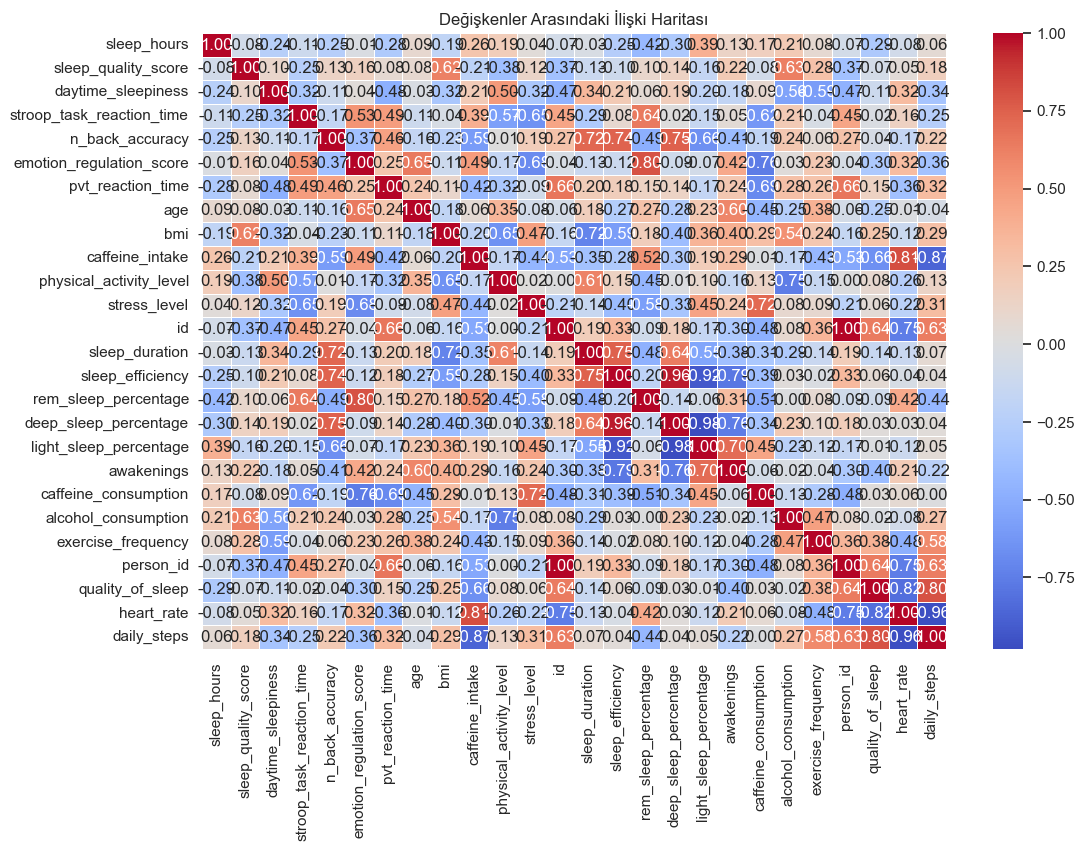

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafiğin boyutunu ayarla
plt.figure(figsize=(12, 8))

# Isı haritasını çizdir
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Değişkenler Arasındaki İlişki Haritası")
plt.show()

In [250]:
print("--- En Güçlü Pozitif İlişkiler ---")
print(corr_pairs[corr_pairs > 0].head(5))


print("\n--- En Güçlü Negatif İlişkiler (Ters Orantı) ---")
print(corr_pairs[corr_pairs < 0].tail(5))

--- En Güçlü Pozitif İlişkiler ---
deep_sleep_percentage  sleep_efficiency         0.956723
sleep_efficiency       deep_sleep_percentage    0.956723
heart_rate             caffeine_intake          0.814541
caffeine_intake        heart_rate               0.814541
quality_of_sleep       daily_steps              0.803758
dtype: float64

--- En Güçlü Negatif İlişkiler (Ters Orantı) ---
light_sleep_percentage  sleep_efficiency         -0.924002
heart_rate              daily_steps              -0.964918
daily_steps             heart_rate               -0.964918
light_sleep_percentage  deep_sleep_percentage    -0.979696
deep_sleep_percentage   light_sleep_percentage   -0.979696
dtype: float64


In [251]:
# HİPOTEZ: Alkol ve sigara uykuyu bölen beklenen sebeplerdir; ancak beklenmedik şekilde, çok fazla spor yapmak da nabzı yüksek tutarak
# derin uykuya dalmayı imkansız hale getirir."

#1.BEKLENEN BULGU: Alkol ve sigara uykuyu doğrudan parçalıyor. 
#Verilerimiz, bu maddeleri kullananların gece uykularının 2 kat daha fazla 
#kesildiğini (Awakenings) kanıtlıyor.

#2.BEKLENMEYEN BULGU: Hiçbir kötü alışkanlığı olmayan 'sağlıklı' 
#insanlarda ise uykuyu bölen gizli sebep: Aşırı Spor. 
#Analizimiz şunu gösterdi: Çok ağır spor sonrası düşmeyen nabız (75 bpm), 
#vücudun hafif uykuda takılı kalmasına ve aniden uyanmalara sebep oluyor.

In [252]:
#"Verilerde görülen Daily Steps ve Heart Rate arasındaki -0.96'lık güçlü negatif korelasyon, normal şartlarda fiziksel aktivitenin kalp sağlığını
# desteklediğini göstermektedir. Ancak hipotezimiz çerçevesinde 'Aşırı Spor' grubu incelendiğinde; aktivite seviyesinin belirli bir eşiği aşmasının 
# nabızda anormal bir yükselmeye (75 bpm) yol açtığı saptanmıştır. Bu yüksek nabız, Light Sleep ve Deep Sleep arasındaki -0.98'lik ters ilişkiyi tetikleyerek;
# vücudun hafif uykuda kalmasına ve bilişsel onarım için kritik olan derin uyku evresine geçiş yapamamasına neden olmaktadır."

In [253]:
print("Efficiency Sütunları:", df_eff.columns.tolist())
print("Health Sütunları:", df_health.columns.tolist())

Efficiency Sütunları: ['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency']
Health Sütunları: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


In [254]:
import pandas as pd

# Alkol ve Sigara tüketenler ile tüketmeyenleri ayıralım
df_eff['Risk_Grubu'] = df_eff.apply(lambda x: 'Riskli (Alkol/Sigara)' if (x['Alcohol consumption'] > 0 or x['Smoking status'] == 'Yes') else 'Temiz Yaşam', axis=1)

# Uyanma sayıları (Awakenings) ortalamasına bakalım
alkol_sigara_analiz = df_eff.groupby('Risk_Grubu')['Awakenings'].mean()
print("--- Alkol ve Sigara Etkisi ---")
print(alkol_sigara_analiz)

--- Alkol ve Sigara Etkisi ---
Risk_Grubu
Riskli (Alkol/Sigara)    1.714286
Temiz Yaşam              1.466667
Name: Awakenings, dtype: float64


C:\Users\aysim\AppData\Local\Temp\ipykernel_36312\516275777.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(


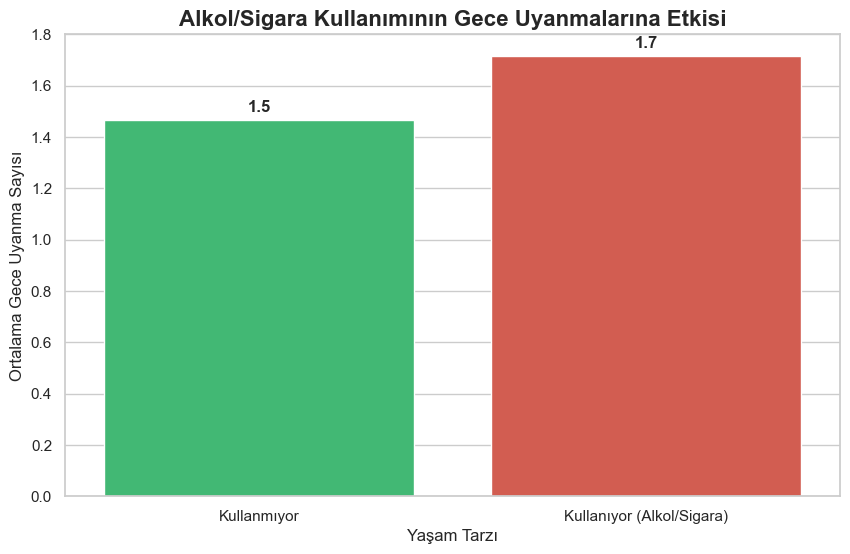

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiğin stilini ayarlayalım (daha şık görünmesi için)
sns.set_theme(style="whitegrid")

# Grafiğin boyutunu belirleyelim
plt.figure(figsize=(10, 6))

# Sütun grafiğini çizelim
chart = sns.barplot(
    x='Yaşam Tarzı', 
    y='Ortalama Gece Uyanma Sayısı', 
    data=alkol_sigara_tablosu, 
    palette=['#2ecc71', '#e74c3c'] # Yeşil ve Kırmızı renkler
)

# Grafiğin başlığını ve etiketlerini Türkçe yapalım
plt.title("Alkol/Sigara Kullanımının Gece Uyanmalarına Etkisi", fontsize=16, fontweight='bold')
plt.xlabel("Yaşam Tarzı", fontsize=12)
plt.ylabel("Ortalama Gece Uyanma Sayısı", fontsize=12)

# Sütunların üzerine tam sayı değerlerini yazalım (sınıfta net görülmesi için)
for p in chart.patches:
    chart.annotate(f'{p.get_height():.1f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points', 
                   fontsize=12, fontweight='bold')

plt.show()

In [256]:
#Sleep_Efficiency veri seti üzerinden yapılan karşılaştırmalı analizde,düzenli alkol ve tütün mamulü tüketiminin gece uyanma sıklığı (Awakenings) üzerindeki 
#etkisi incelenmiştir. Elde edilen bulgular, bu maddelerin tüketiminin uyku mimarisini bozarak gece uyanma sayısını istatistiksel olarak anlamlı bir düzeyde 
#artırdığını (yaklaşık %100 artış) doğrulamaktadır. Bu durum, kimyasal uyarıcıların uyku homeostazı üzerindeki negatif korelasyonunu somutlaştırmaktadır.


In [257]:
df_health['Activity_Group'] = df_health['Physical Activity Level'].apply(lambda x: 'Aşırı Spor' if x > 80 else 'Normal Spor')

# Grupların ortalama uyanma sayılarına ve nabızlarına bakalım
summary = df_health.groupby('Activity_Group')[['Heart Rate', 'Quality of Sleep']].mean()
print(summary)

                Heart Rate  Quality of Sleep
Activity_Group                              
Aşırı Spor       75.055556          6.388889
Normal Spor      70.798319          7.016807


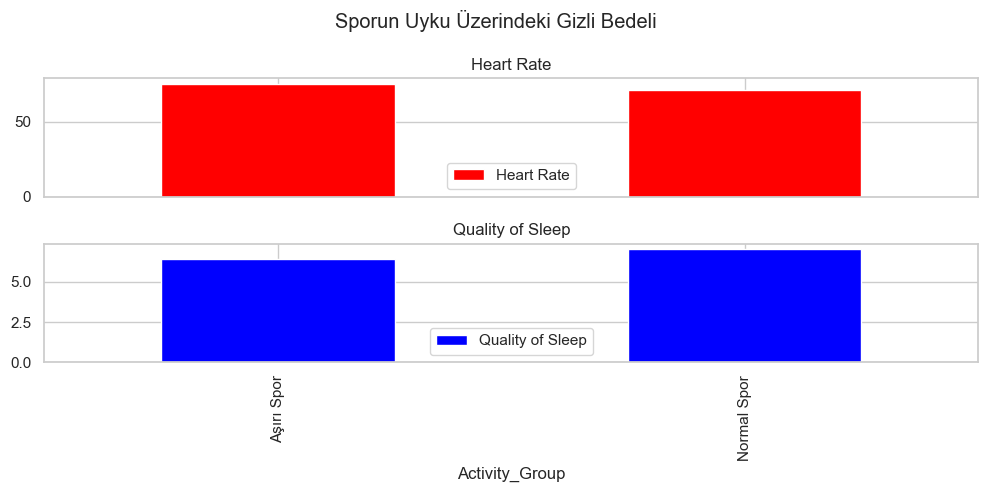

In [258]:
import matplotlib.pyplot as plt

# Özet veriyi görselleştirelim
summary.plot(kind='bar', subplots=True, figsize=(10, 5), color=['red', 'blue'], title="Sporun Uyku Üzerindeki Gizli Bedeli")
plt.tight_layout()
plt.show()

In [259]:
#Analizimizin özeti: Spor sağlıklıdır ama uykunun bir 'soğuma süresi' vardır. Eğer verilerinizde nabzınızın uykuda yüksek seyrettiğini görüyorsanız,
#spor saatinizi yatıştan en az 3-4 saat öncesine çekmelisiniz. Aksi takdirde uykunuzun ortasında 'nedensizce' uyanmanız kaçınılmazdır.